In [1]:
import os
import pandas as pd
import torch
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from scripts.variable_leverage_env_3 import agentDLVEnvV3
from scripts.utils import plot_economic_metrics, plot, plot_episode_history_v2
from torch_model_v2 import reccurentActor

In [ ]:
WIDTH = 0.1
TOP_LEVERAGE = 2 + WIDTH/2
BOTTOM_LEVERAGE = 2 - WIDTH/2

In [3]:
df = pd.read_csv('wbtc_train_data_expanded.csv')
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values

nav = nav[::4]
nect_price = nect_price[::4]
vol_token_price = vol_token_price[::4]
volatile_part = volatile_part[::4]

In [4]:
eval_env = DummyVecEnv([lambda: agentDLVEnvV3(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_mixed = True,
    top_leverage = TOP_LEVERAGE,
    bottom_leverage = BOTTOM_LEVERAGE
)])

model_1 = RecurrentPPO.load(
    "variable_leverage_model_v3_phase_2/ppo_model_phase_2", 
    env=eval_env,
    custom_objects={"lr_schedule": lambda _: 0.0, "learning_rate": 0.0}
)

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1


doing nothing 99.89620095495123 %
action 1 0.10379904504878555 %
action 2 0.0 %
action 3 0.0 %


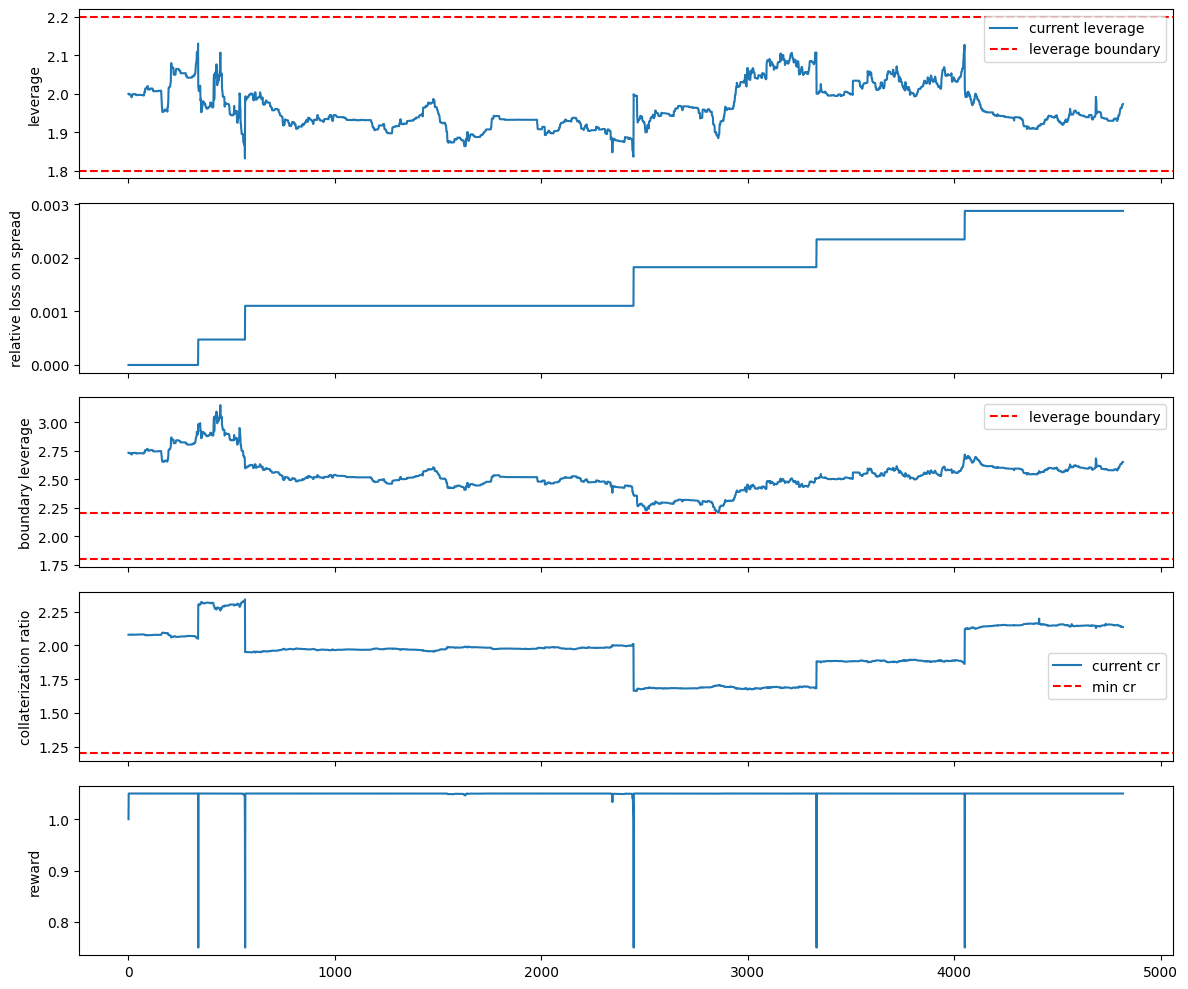

In [5]:
obs = eval_env.reset()  
done = False
while not done:
    action, _ = model_1.predict(obs, deterministic=True)  
    obs, rewards, dones, infos = eval_env.step(action)
    done = dones[0]
    if dones[0]:
        economic_metrics = infos[0].get('episode_economics')
        episode_history = infos[0].get('episode_history')   
        not_doing = infos[0].get('0 action')  
        action_1 = infos[0].get('0.5 rebalancing') 
        action_2 = infos[0].get('0.75 rebalancing') 
        action_3 = infos[0].get('0.25 rebalancing') 
        break

print('doing nothing', not_doing*100, '%')
print('action 1', action_1*100, '%')
print('action 2', action_2*100, '%')
print('action 3', action_3*100, '%')

plot_episode_history_v2(episode_history, TOP_LEVERAGE, BOTTOM_LEVERAGE)

In [7]:
model = reccurentActor()
model.set_initial_state('actor_weights_v2.pth')

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1
doing nothing 99.95848038198048 %
action 1 0.041519618019514225 %
action 2 0.0 %
action 3 0.0 %


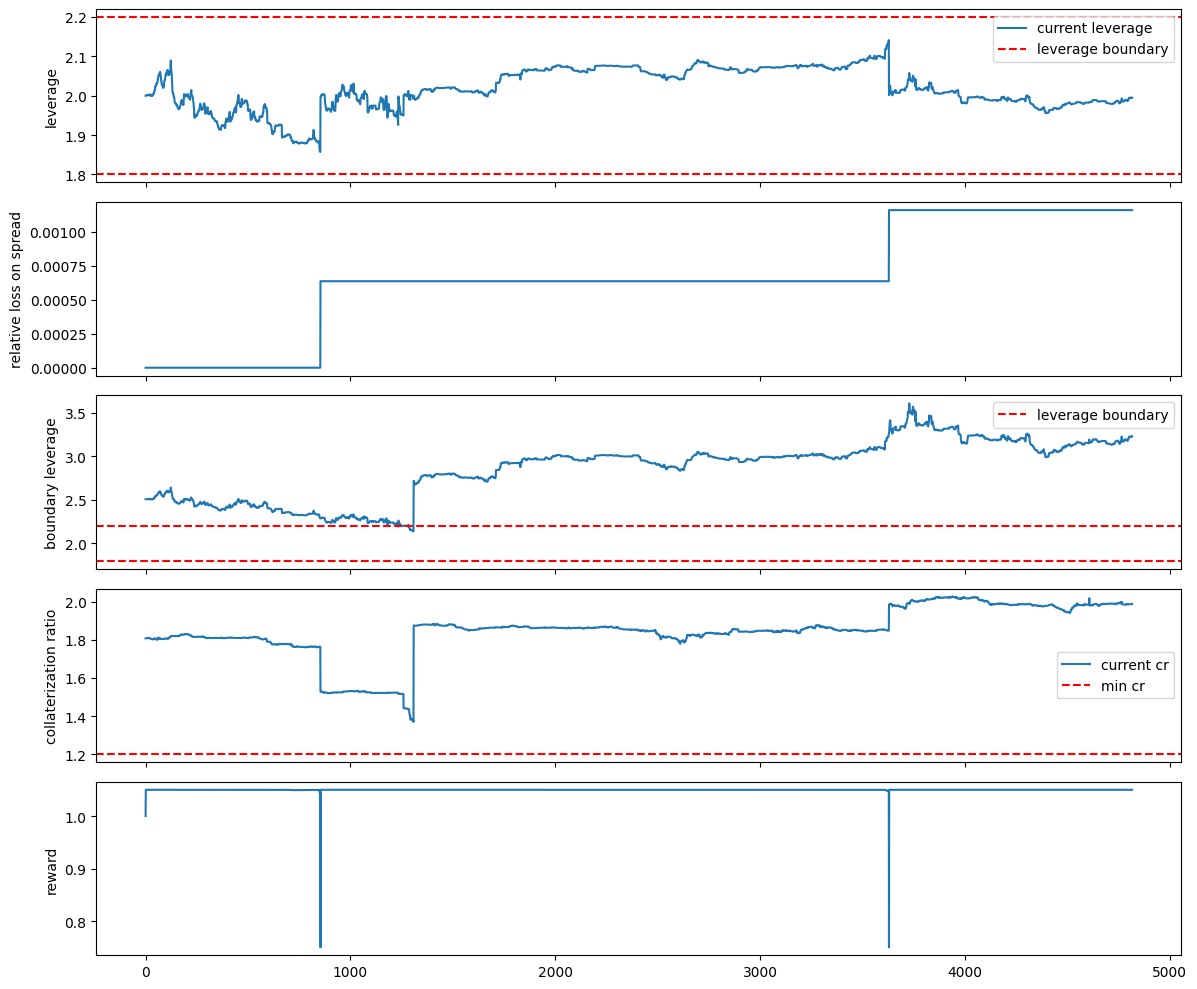

In [8]:
eval_env = agentDLVEnvV3(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = False,
    is_mixed = True,
    is_reversed = True,
    top_leverage= TOP_LEVERAGE,
    bottom_leverage = BOTTOM_LEVERAGE
)

obs, _ = eval_env.reset(seed= 4)
done = False
hidden = model.init_hidden(batch_size=1, device='cpu')

while not done:
    #print(obs)
    action, log_prob, _, hidden = model.act(obs, hidden)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

history = info['episode_history']
history_metrics = info['episode_metrics']
economic_metrics = info['episode_economics']
t_l = info['top leverage']
b_l = info['bottom leverage']
not_doing = info.get('0 action')  
action_1 = info.get('0.5 rebalancing') 
action_2 = info.get('0.75 rebalancing') 
action_3 = info.get('0.25 rebalancing') 

print('doing nothing', not_doing*100, '%')
print('action 1', action_1*100, '%')
print('action 2', action_2*100, '%')
print('action 3', action_3*100, '%')

plot_episode_history_v2(history, t_l, b_l)